# Skinning Weight Training Analysis

This notebook analyses whether the **skinning weight training** is working well.

It does this by:
1. **Training** a `SimplicitsObject` (neural skinning weights, physics losses).
2. **Creating a heuristic** `SimplicitsObject` (constant or spatially-partitioned weights — no training).
3. **Plotting training loss curves** (total, elastic, ortho, sim2real, grad norm) → saved to `PLOTS_OUTPUT_DIR`.
4. **Qualitative/quantitative skinning weight analysis** (dominant-handle coloring, max-weight histogram, entropy) → saved.
5. **Side-by-side simulation comparison** (trained vs heuristic) with per-frame Chamfer + grasp error logging.
6. **Simulation metric plots** → saved.


In [1]:
# ================================================================
# CONFIG  ← edit these before running
# ================================================================
import os

PLOTS_OUTPUT_DIR = "./skinning_weight_analysis_plots"   # where to save all PNGs
TRAINING_LOG_DIR = "./runs_skinning_weight_analysis"    # where to save training ckpts + CSV

NUM_HANDLES      = 5       # LBS handles for the trained model
TRAINING_STEPS   = 15000  # more steps so lo has time to drive handles apart
LAMBDA_E         = 1e-1   # elastic loss coefficient
LAMBDA_O         = 1e8    # orthogonality loss coeff — raised from 1e6 to prevent
                           # the uniform-weight collapse seen in the first run

# Heuristic type for the *untrained* object (no neural training):
#   "uniform"     – every point gets equal weight 1/H per handle
#   "spatial"     – k-means handle locs + softmax-distance weighting
#   "random_init" – un-trained MLP (random network weights)
HEURISTIC_TYPE   = "spatial"

# Set to True if you also want sim2real supervision during training
# (requires tool + real frames, defined later)
USE_SIM2REAL_TRAINING = False

os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
os.makedirs(TRAINING_LOG_DIR, exist_ok=True)
print(f"Plots  → {os.path.abspath(PLOTS_OUTPUT_DIR)}")
print(f"Runs   → {os.path.abspath(TRAINING_LOG_DIR)}")

Plots  → /home/nan/Desktop/kaolin/examples/tutorial/physics/skinning_weight_analysis_plots
Runs   → /home/nan/Desktop/kaolin/examples/tutorial/physics/runs_skinning_weight_analysis


In [2]:
# ================================================================
# IMPORTS
# ================================================================
import sys, pickle, json, time, threading, csv
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import k3d

sys.path.insert(0, "/home/nan/Desktop/kaolin")
import kaolin as kal

import kaolin.physics.simplicits.easy_api_sim2real_UPDATED_anchor_boundary_fastckpt_v3 as ez
from kaolin.physics.simplicits.network import SimplicitsMLP
from kaolin.physics.simplicits.easy_api_sim2real_UPDATED_anchor_boundary_fastckpt_v3 import NormalizedSkinningWeightsFcn

print("kaolin:", kal.__file__)
print("torch:", torch.__version__, "  CUDA:", torch.cuda.is_available())

kaolin: /home/nan/Desktop/kaolin/kaolin/__init__.py
torch: 2.8.0+cu129   CUDA: True


## 1) Load tissue point cloud from PKL

In [3]:
pkl_file_path = "/home/nan/Desktop/datasets/xpbd/StereoMIS_tissue_tool_trajectories_XPBD/sim_particles/tissue_pts_dnsampled_once.pkl"

with open(pkl_file_path, "rb") as f:
    real_seq = pickle.load(f)

print(type(real_seq), "  frames:", len(real_seq))
print("keys:",  real_seq[0].keys())
print("xyz:",   np.asarray(real_seq[0]["xyz"]).shape)

<class 'list'>   frames: 200
keys: dict_keys(['frame_id', 'xyz', 'rgb', 'opacity', 'indices'])
xyz: (38426, 3)


## 2) Choose rest frame, normalise, load all frames

In [4]:
# Frame 75 is the first frame at which the tool appears in the sequence,
# so we use it as the tissue rest / initial state for both training and simulation.
rest_frame_idx = 75

# Find the list index whose frame_id == rest_frame_idx
_rest_list_idx = next(
    i for i, fr in enumerate(real_seq) if int(fr["frame_id"]) == rest_frame_idx
)

xyz       = np.asarray(real_seq[_rest_list_idx]["xyz"], dtype=np.float32)
N         = xyz.shape[0]
print(f"Rest frame: id={rest_frame_idx}  list_idx={_rest_list_idx}  N={N}")

pts_raw    = torch.from_numpy(xyz).cuda()
mn         = pts_raw.min(dim=0).values
mx         = pts_raw.max(dim=0).values
center_raw = 0.5 * (mn + mx)
scale_raw  = float((0.5 * (mx - mn)).max().item())

pts      = (pts_raw - center_raw) / max(scale_raw, 1e-8)
orig_pts = pts.clone()

print("raw bbox:   ", mn.cpu().numpy(), mx.cpu().numpy())
print("center_raw:", center_raw.cpu().numpy(), "  scale_raw:", scale_raw)
print("normed bbox:", pts.min(0).values.cpu().numpy(), pts.max(0).values.cpu().numpy())

Rest frame: id=75  list_idx=75  N=45038
raw bbox:    [-0.8533555 -1.0274289  0.5846553] [0.67263234 0.4106261  1.8220112 ]
center_raw: [-0.0903616  -0.30840138  1.2033333 ]   scale_raw: 0.7629939317703247
normed bbox: [-1.         -0.94237643 -0.8108557 ] [1.         0.94237643 0.8108557 ]


In [5]:
real_xyz_norm  = []
real_frame_ids = []
for fr in real_seq:
    real_frame_ids.append(int(fr["frame_id"]))
    xyz_t    = torch.from_numpy(np.asarray(fr["xyz"], dtype=np.float32)).to(pts.device)
    xyz_norm = (xyz_t - center_raw) / max(scale_raw, 1e-8)
    real_xyz_norm.append(xyz_norm)

real_frame_to_xyz = {fid: xyz for fid, xyz in zip(real_frame_ids, real_xyz_norm)}
print("Loaded real frames:", real_frame_ids[0], "->", real_frame_ids[-1])

Loaded real frames: 0 -> 199


## 3) Quick visualisation of rest point cloud

In [6]:
plot_rest = k3d.plot()
plot_rest += k3d.points(orig_pts.detach().cpu().numpy(), point_size=0.01)
plot_rest.display()

Output()

## 4) Material fields

In [7]:
yms  = torch.full((N,), 2e5,   device=pts.device, dtype=pts.dtype)
prs  = torch.full((N,), 0.45,  device=pts.device, dtype=pts.dtype)
rhos = torch.full((N,), 1000., device=pts.device, dtype=pts.dtype)

mn_n, mx_n   = pts.min(0).values, pts.max(0).values
approx_volume = max(float(torch.prod(mx_n - mn_n).item()), 1e-6)
print("approx_volume:", approx_volume)

approx_volume: 6.11305046081543


## 5) Load tool trajectory and align with real frames

In [8]:
tool_pkl_path = "/home/nan/Desktop/datasets/xpbd/StereoMIS_tissue_tool_trajectories_XPBD/sim_particles/tool_3d_poses.pkl"
with open(tool_pkl_path, "rb") as f:
    tool_data = pickle.load(f)

frame_ids   = sorted(tool_data.keys())
tool_t_raw  = np.stack([np.asarray(tool_data[k]["t"], dtype=np.float32) for k in frame_ids])
tool_R_raw  = np.stack([np.asarray(tool_data[k]["R"], dtype=np.float32) for k in frame_ids])

tool_t_raw_t = torch.from_numpy(tool_t_raw).to(device=pts.device, dtype=pts.dtype)
tool_R       = torch.from_numpy(tool_R_raw).to(device=pts.device, dtype=pts.dtype)
tool_t       = (tool_t_raw_t - center_raw) / max(scale_raw, 1e-8)

# Keep only tool frames that also have real observations
aligned_frame_ids     = [fid for fid in frame_ids if fid in real_frame_to_xyz]
idx_map               = [frame_ids.index(fid) for fid in aligned_frame_ids]
tool_t                = tool_t[idx_map]
tool_R                = tool_R[idx_map]
frame_ids             = aligned_frame_ids
real_xyz_norm_aligned = [real_frame_to_xyz[fid] for fid in frame_ids]

T_total = len(frame_ids)

# No sim2real training yet → no train/test split needed.
# Use ALL tool frames for simulation evaluation (ti = 0 … T_total-1).
train_T = 0          # placeholder; kept so sim logging code can label splits
eval_T0 = 0          # simulation starts from the very first tool frame (video frame 75)
eval_T1 = T_total    # simulation runs through all tool frames

print(f"Tool frames: {frame_ids[0]} -> {frame_ids[-1]}  count={T_total}")
print(f"Sim eval:    ti in [0, {eval_T1})  (all frames, no train/test split)")

Tool frames: 75 -> 199  count=125
Sim eval:    ti in [0, 125)  (all frames, no train/test split)


## 6) Train SimplicitsObject with full loss logging

Trains the neural skinning weight field using physics-based losses (elastic + orthogonality).  
Set `USE_SIM2REAL_TRAINING = True` in the config cell to also supervise with Chamfer-to-real.

After training the losses CSV is at `sim_obj_trained.training_log_csv`.

In [9]:
stamp     = datetime.now().strftime("%Y%m%d-%H%M%S")
train_dir = os.path.join(TRAINING_LOG_DIR, f"{stamp}_trained_H{NUM_HANDLES}_lo{LAMBDA_O:.0e}")
os.makedirs(train_dir, exist_ok=True)

common_train_kwargs = dict(
    num_handles            = NUM_HANDLES,
    training_num_steps     = TRAINING_STEPS,
    training_lr_start      = 1e-3,
    training_lr_end        = 1e-3,
    training_le_coeff      = LAMBDA_E,
    training_lo_coeff      = LAMBDA_O,   # raised from 1e6 → drives handles to be spatially distinct
    training_log_every     = 100,
    normalize_for_training = True,
    training_batch_size    = 10,
    num_samples            = 800,
    training_save_every    = 500,
    training_eval_every    = 500,
    training_resume        = True,
    training_log_dir       = train_dir,
    training_return_logs   = True,       # get loss history back as a dict
)

if USE_SIM2REAL_TRAINING:
    s2r_kwargs = dict(
        training_ls_coeff           = 1.0,
        sim2real_real_frames        = real_xyz_norm_aligned,
        sim2real_train_range        = (0, train_T) if train_T > 0 else (0, min(60, T_total)),
        sim2real_num_pts_sim        = 1024,
        sim2real_num_pts_real       = 1024,
        sim2real_tool_t             = tool_t,
        sim2real_tool_R             = tool_R,
        sim2real_use_rotation       = False,
        sim2real_scene_num_qp       = 800,
        sim2real_scene_timestep     = 0.01,
        sim2real_scene_newton_steps = 30,
        sim2real_max_steps_per_call = 50,
        sim2real_anchor_enable      = True,
        sim2real_anchor_eps_ratio   = 0.03,
        sim2real_anchor_penalty     = 1e7,
        sim2real_grasp_penalty      = 1e5,
        sim2real_every              = 50,
        sim2real_warmup_steps       = 200,
    )
    common_train_kwargs.update(s2r_kwargs)
else:
    common_train_kwargs["training_ls_coeff"] = 0.0

print(f"Training config:  steps={TRAINING_STEPS}  lambda_e={LAMBDA_E:.0e}  lambda_o={LAMBDA_O:.0e}  H={NUM_HANDLES}")
print(f"Log dir: {train_dir}")

sim_obj_trained, train_logs = ez.SimplicitsObject.create_trained(
    pts, yms, prs, rhos, approx_volume,
    **common_train_kwargs,
)

print("Trained object:", sim_obj_trained)
print("num_handles    :", sim_obj_trained.num_handles)
print("Log CSV        :", sim_obj_trained.training_log_csv)
print("Log dir        :", train_dir)

Training config:  steps=15000  lambda_e=1e-01  lambda_o=1e+08  H=5
Log dir: ./runs_skinning_weight_analysis/20260414-221321_trained_H5_lo1e+08


  0%|          | 0/15000 [00:00<?, ?it/s]

Trained object: <kaolin.physics.simplicits.easy_api_sim2real_UPDATED_anchor_boundary_fastckpt_v3.SimplicitsObject object at 0x7d6615b8b850>
num_handles    : 6
Log CSV        : ./runs_skinning_weight_analysis/20260414-221321_trained_H5_lo1e+08/train_losses.csv
Log dir        : ./runs_skinning_weight_analysis/20260414-221321_trained_H5_lo1e+08


## 7) Create heuristic SimplicitsObject (no training)

Builds a weight function using a rule (no gradient descent).  
Controlled by `HEURISTIC_TYPE` in the config cell:
- **`uniform`** – equal weights `1/H` for every point and every handle
- **`spatial`** – k-means handle locations + softmax of negative distance (soft Voronoi)
- **`random_init`** – un-trained MLP with random network weights

In [10]:
H = NUM_HANDLES   # raw MLP output size; wrapper adds +1 constant handle to match trained

if HEURISTIC_TYPE == "uniform":
    # -------------------------------------------------------
    # Uniform: 1/H weight per handle, plus constant 1 appended
    # -------------------------------------------------------
    def heuristic_weight_fn(x):
        N_x  = x.shape[0]
        base = torch.full((N_x, H), 1.0 / H, device=x.device, dtype=x.dtype)
        const = torch.ones((N_x, 1),         device=x.device, dtype=x.dtype)
        return torch.cat([base, const], dim=1)   # (N, H+1)

elif HEURISTIC_TYPE == "spatial":
    # -------------------------------------------------------
    # Spatial (soft-Voronoi): k-means centres + softmax distance
    # -------------------------------------------------------
    from sklearn.cluster import KMeans
    pts_np      = pts.detach().cpu().numpy()
    kmeans      = KMeans(n_clusters=H, random_state=42, n_init=10).fit(pts_np)
    _handle_locs = torch.from_numpy(kmeans.cluster_centers_.astype(np.float32)).to(pts.device)
    _TEMP        = 0.1   # temperature: lower → harder (one-hot) assignment

    print("K-Means handle locations (normed):")
    for i, loc in enumerate(_handle_locs):
        print(f"  handle {i}: {loc.cpu().numpy()}")

    def heuristic_weight_fn(x):
        d     = torch.cdist(x, _handle_locs)                # (N, H) L2 distances
        base  = torch.softmax(-d / _TEMP, dim=1)            # (N, H) soft Voronoi
        const = torch.ones((x.shape[0], 1), device=x.device, dtype=x.dtype)
        return torch.cat([base, const], dim=1)              # (N, H+1)

elif HEURISTIC_TYPE == "random_init":
    # -------------------------------------------------------
    # Random init: same architecture as trained, but no training
    # -------------------------------------------------------
    _rand_model = SimplicitsMLP(3, 64, H, 6).to(pts.device)
    _rand_model.eval()
    _bb_min = pts.min(dim=0).values
    _bb_max = pts.max(dim=0).values

    # Wrap the same way as NormalizedSkinningWeightsFcn
    class _RandInitFcn(torch.nn.Module):
        def __init__(self, m, bb_min, bb_max):
            super().__init__()
            self.m = m
            self.bb_min = bb_min
            self.bb_max = bb_max
        @torch.no_grad()
        def forward(self, x):
            normed = (x - self.bb_min) / (self.bb_max - self.bb_min).clamp_min(1e-8)
            logits = self.m(normed)                                          # (N, H)
            const  = torch.ones(x.shape[0], 1, device=x.device, dtype=x.dtype)
            return torch.cat([logits, const], dim=1)                         # (N, H+1)

    _rand_fn = _RandInitFcn(_rand_model, _bb_min, _bb_max)
    heuristic_weight_fn = _rand_fn

else:
    raise ValueError(f"Unknown HEURISTIC_TYPE: {HEURISTIC_TYPE!r}")

sim_obj_heuristic = ez.SimplicitsObject.create_from_function(
    pts, yms, prs, rhos, approx_volume,
    fcn=heuristic_weight_fn,
)
print("Heuristic object:", sim_obj_heuristic)
print("num_handles     :", sim_obj_heuristic.num_handles, f"  (type={HEURISTIC_TYPE!r})")

K-Means handle locations (normed):
  handle 0: [0.35408926 0.1664651  0.19549218]
  handle 1: [-0.36029923  0.7098102  -0.24464618]
  handle 2: [ 0.7239546   0.51510155 -0.1591804 ]
  handle 3: [ 0.11086851 -0.33698308  0.1695104 ]
  handle 4: [-0.38978213  0.12407853  0.52871054]
Heuristic object: <kaolin.physics.simplicits.easy_api_sim2real_UPDATED_anchor_boundary_fastckpt_v3.SimplicitsObject object at 0x7d6615bd8040>
num_handles     : 6   (type='spatial')


## 8) Training loss analysis → save plots to `PLOTS_OUTPUT_DIR`

Loads the per-step CSV written during training and plots all loss components.

Training log: 151 rows  columns: ['step', 'lr', 'le', 'lo', 'ls', 'total', 'grad_norm', 'elapsed_s']


,step,lr,le,lo,ls,total,grad_norm,elapsed_s
146,14600,0.001,2400.134277,294894.59375,0.0,297294.71875,63688300.0,47.148804
147,14700,0.001,1427.054688,401914.34375,0.0,403341.40625,53221316.0,47.463101
148,14800,0.001,1383.291260,290355.18750,0.0,291738.46875,65590204.0,47.770491
149,14900,0.001,2226.469727,199670.18750,0.0,201896.65625,40573592.0,48.073524
150,14999,0.001,1443.753296,412020.59375,0.0,413464.34375,74558792.0,48.366757


Saved: ./skinning_weight_analysis_plots/01_loss_all_components.png


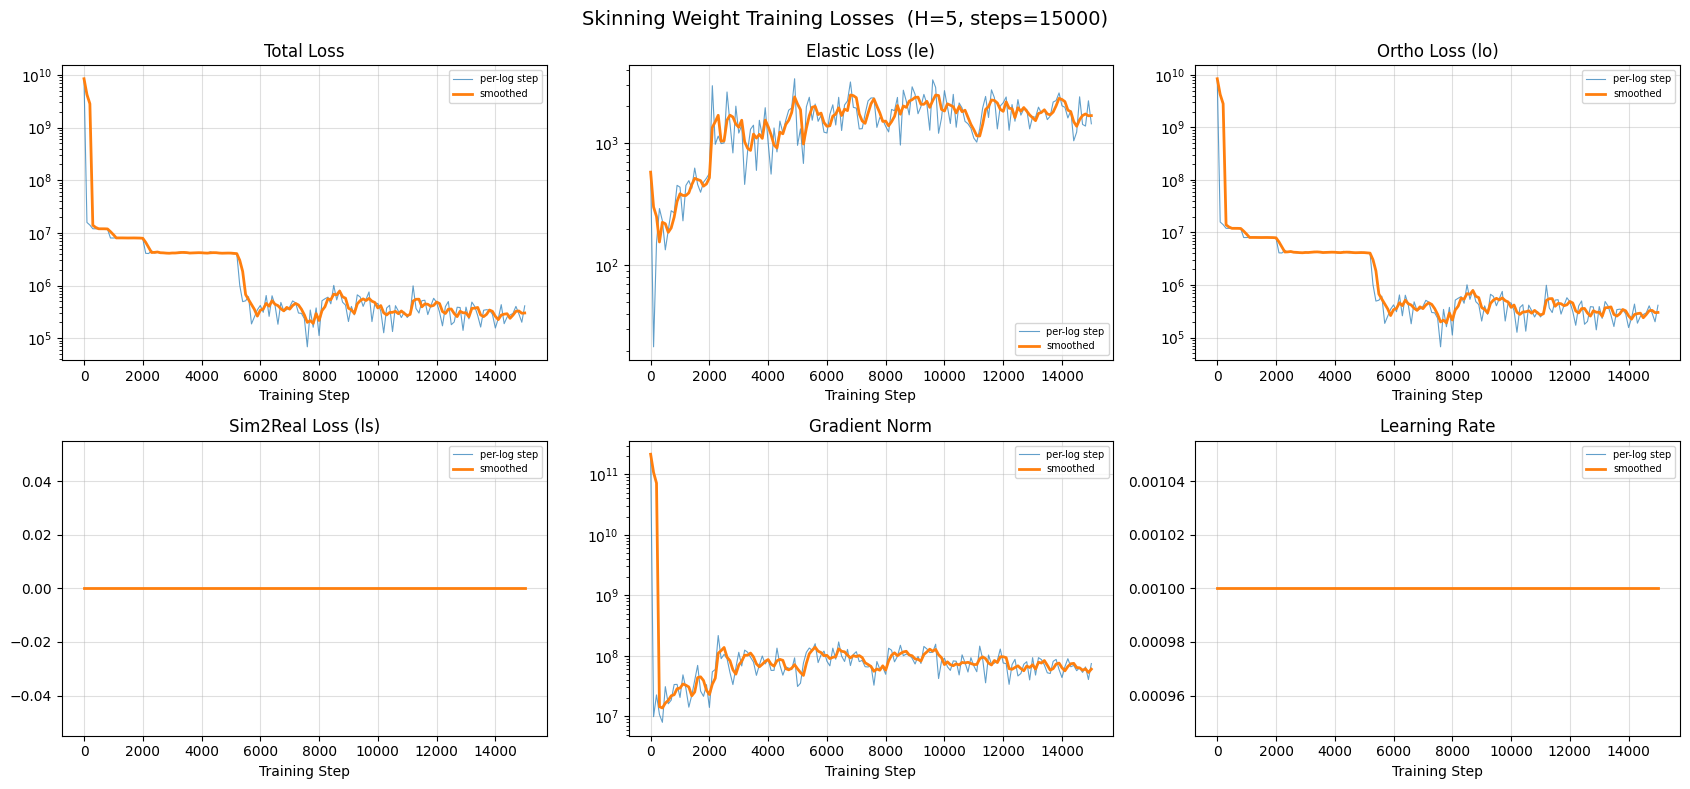

Saved: ./skinning_weight_analysis_plots/02_loss_convergence.png


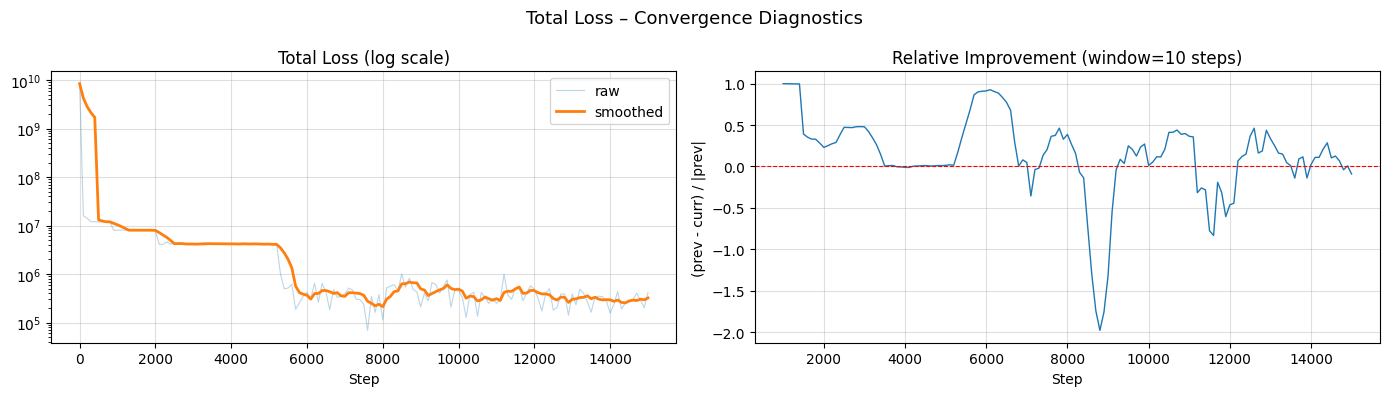


=== Training Loss Summary ===
  total     :  first=8.458e+09  last=4.135e+05  last-20%-mean=3.034e+05  ratio(last/first)=0.000
  le        :  first=5.806e+02  last=1.444e+03  last-20%-mean=1.804e+03  ratio(last/first)=2.486
  lo        :  first=8.458e+09  last=4.120e+05  last-20%-mean=3.016e+05  ratio(last/first)=0.000
  ls        :  first=0.000e+00  last=0.000e+00  last-20%-mean=0.000e+00  ratio(last/first)=0.000
  grad_norm :  first=2.153e+11  last=7.456e+07  last-20%-mean=6.566e+07  ratio(last/first)=0.000


In [11]:
train_csv = sim_obj_trained.training_log_csv
if not os.path.exists(train_csv):
    raise FileNotFoundError(f"Training CSV not found: {train_csv}")

df_train = pd.read_csv(train_csv)
print(f"Training log: {len(df_train)} rows  columns: {list(df_train.columns)}")
display(df_train.tail())

# ---- Panel 1: all loss components ----
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
fig.suptitle(f"Skinning Weight Training Losses  (H={NUM_HANDLES}, steps={TRAINING_STEPS})", fontsize=14)

panels = [
    ("total",     "Total Loss",            axes[0, 0], True),
    ("le",        "Elastic Loss (le)",      axes[0, 1], True),
    ("lo",        "Ortho Loss (lo)",        axes[0, 2], True),
    ("ls",        "Sim2Real Loss (ls)",     axes[1, 0], True),
    ("grad_norm", "Gradient Norm",          axes[1, 1], True),
    ("lr",        "Learning Rate",          axes[1, 2], False),
]

for col, title, ax, use_log in panels:
    if col not in df_train.columns or df_train[col].dropna().empty:
        ax.set_title(f"{title}  (N/A)")
        ax.axis("off")
        continue
    vals = df_train[col].dropna()
    steps_col = df_train.loc[vals.index, "step"]
    ax.plot(steps_col, vals, linewidth=0.8, alpha=0.7, label="per-log step")
    # smoothed overlay
    smooth = vals.rolling(max(1, len(vals)//50), min_periods=1).mean()
    ax.plot(steps_col, smooth, linewidth=2, label="smoothed")
    ax.set_title(title)
    ax.set_xlabel("Training Step")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
    if use_log and vals.min() > 0:
        ax.set_yscale("log")

plt.tight_layout()
p1 = os.path.join(PLOTS_OUTPUT_DIR, "01_loss_all_components.png")
plt.savefig(p1, dpi=150, bbox_inches="tight")
print("Saved:", p1)
plt.show()

# ---- Panel 2: total loss zoomed + convergence diagnostics ----
if "total" in df_train.columns:
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
    fig2.suptitle("Total Loss – Convergence Diagnostics", fontsize=13)

    total = df_train["total"].dropna()
    steps = df_train.loc[total.index, "step"]
    smooth = total.rolling(max(1, len(total)//30), min_periods=1).mean()

    axes2[0].plot(steps, total, alpha=0.3, lw=0.8, label="raw")
    axes2[0].plot(steps, smooth, lw=2, label="smoothed")
    axes2[0].set_title("Total Loss (log scale)")
    axes2[0].set_xlabel("Step"); axes2[0].set_yscale("log")
    axes2[0].legend(); axes2[0].grid(True, alpha=0.4)

    # Relative improvement per window (convergence indicator)
    window = max(10, len(total)//20)
    rel_improv = (smooth.shift(window) - smooth) / (smooth.shift(window).abs() + 1e-12)
    axes2[1].plot(steps, rel_improv, lw=1)
    axes2[1].axhline(0, color="red", lw=0.8, linestyle="--")
    axes2[1].set_title(f"Relative Improvement (window={window} steps)")
    axes2[1].set_xlabel("Step"); axes2[1].grid(True, alpha=0.4)
    axes2[1].set_ylabel("(prev - curr) / |prev|")

    plt.tight_layout()
    p2 = os.path.join(PLOTS_OUTPUT_DIR, "02_loss_convergence.png")
    plt.savefig(p2, dpi=150, bbox_inches="tight")
    print("Saved:", p2)
    plt.show()

# ---- Quantitative training summary ----
print("\n=== Training Loss Summary ===")
for col in ["total", "le", "lo", "ls", "grad_norm"]:
    if col in df_train.columns:
        v = df_train[col].dropna()
        if len(v) == 0:
            continue
        n20 = max(1, len(v)//5)
        print(f"  {col:10s}:  first={v.iloc[0]:.3e}  last={v.iloc[-1]:.3e}  "
              f"last-20%-mean={v.iloc[-n20:].mean():.3e}  "
              f"ratio(last/first)={v.iloc[-1]/(v.iloc[0]+1e-30):.3f}")

## 9) Skinning weight quality analysis → save plots

Compares the **trained** and **heuristic** weight fields with three diagnostics:
1. **Dominant handle** coloring projected onto XY / XZ / YZ planes.
2. **Max weight per point** histogram — how concentrated the assignment is (1 = perfect hard partition, 1/H = uniform).
3. **Per-point entropy** histogram — lower entropy means sharper handle boundaries.

In [12]:
@torch.no_grad()
def compute_weight_stats(sim_obj, label, subsample=8000):
    idx    = torch.randperm(pts.shape[0])[:subsample]
    pts_s  = pts[idx]
    w_full = sim_obj.skinning_weight_function(pts_s)   # (sub, H+1)
    w_raw  = w_full[:, :-1].detach().cpu().numpy()     # (sub, H) — drop constant column
    pts_np = pts_s.detach().cpu().numpy()

    # ── Raw-logit metrics (honest — no softmax distortion) ──────────────────
    # Dominant handle by raw argmax (invariant to softmax anyway)
    dominant    = np.argmax(w_raw, axis=1)             # (sub,)

    # Logit range per point: max_logit - min_logit
    # = 0 everywhere  →  all handles produce identical output (degenerate)
    # > 0             →  network genuinely differentiates handles at that point
    logit_range = w_raw.max(axis=1) - w_raw.min(axis=1)   # (sub,)
    logit_std   = w_raw.std(axis=1)                        # (sub,) — std across handles

    # ── Handle correlation matrix ────────────────────────────────────────────
    # Normalise each handle's weight vector across sampled points → zero-mean, unit-std
    # Gram matrix of normalised columns measures how correlated the handles are.
    # Ideal (perfectly orthogonal handles): identity matrix.
    # Degenerate (all handles identical): all-ones matrix.
    W_zm  = w_raw - w_raw.mean(axis=0)                    # (sub, H) zero-mean per handle
    W_norm = W_zm / (W_zm.std(axis=0) + 1e-8)             # (sub, H) unit-std per handle
    gram  = (W_norm.T @ W_norm) / w_raw.shape[0]          # (H, H) correlation matrix

    # ── Per-handle spatial maps (raw logit value for each handle) ───────────
    per_handle = w_raw                                     # (sub, H)

    return dict(
        pts=pts_np, w_raw=w_raw,
        dominant=dominant, logit_range=logit_range, logit_std=logit_std,
        gram=gram, per_handle=per_handle, label=label,
    )

print("Computing weight stats for trained model ...")
stats_trained   = compute_weight_stats(sim_obj_trained,   f"Trained (H={NUM_HANDLES}, {TRAINING_STEPS} steps)")
print("Computing weight stats for heuristic model ...")
stats_heuristic = compute_weight_stats(sim_obj_heuristic, f"Heuristic ({HEURISTIC_TYPE!r})")

# ── Quantitative table (raw-logit based) ─────────────────────────────────────
print("\n=== Skinning Weight Quality — RAW logit metrics ===")
print(f"  {'Metric':<35} {'Trained':>14} {'Heuristic':>14}")
print("  " + "-" * 65)
for metric, t_arr, h_arr in [
    ("Logit range  mean  (>0 = differentiates)", stats_trained['logit_range'], stats_heuristic['logit_range']),
    ("Logit range  std",                          stats_trained['logit_range'], stats_heuristic['logit_range']),
    ("Logit std    mean  (>0 = differentiates)",  stats_trained['logit_std'],   stats_heuristic['logit_std']),
]:
    fn = np.mean if 'mean' in metric else np.std
    print(f"  {metric:<35} {fn(t_arr):>14.4f} {fn(h_arr):>14.4f}")

print("\n  Handle dominance (# points whose argmax = handle h):")
print(f"  {'Handle':<10} {'Trained':>14} {'Heuristic':>14}")
for h in range(NUM_HANDLES):
    ct = (stats_trained['dominant'] == h).sum()
    ch = (stats_heuristic['dominant'] == h).sum()
    print(f"  {h:<10} {ct:>14d} {ch:>14d}")

print("\n  Handle correlation matrix (trained) — ideal = identity:")
gram = stats_trained['gram']
for row in gram:
    print("    " + "  ".join(f"{v:+.3f}" for v in row))
print("  Off-diagonal mean abs corr: {:.4f}  (0=orthogonal, 1=identical)".format(
    (np.abs(gram) - np.eye(NUM_HANDLES)).mean()))

Computing weight stats for trained model ...
Computing weight stats for heuristic model ...

=== Skinning Weight Quality — RAW logit metrics ===
  Metric                                     Trained      Heuristic
  -----------------------------------------------------------------
  Logit range  mean  (>0 = differentiates)         0.0866         0.9078
  Logit range  std                            0.0174         0.1316
  Logit std    mean  (>0 = differentiates)         0.0311         0.3606

  Handle dominance (# points whose argmax = handle h):
  Handle            Trained      Heuristic
  0                       0           1761
  1                    1365           2642
  2                    1377           1560
  3                    2452           1517
  4                    2806            520

  Handle correlation matrix (trained) — ideal = identity:
    +1.000  -0.085  -0.096  +0.756  +0.400
    -0.085  +1.000  -0.026  -0.015  +0.062
    -0.096  -0.026  +1.000  +0.070  -0.018
   

/tmp/ipykernel_2583483/3697814686.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_h = plt.cm.get_cmap("tab10", NUM_HANDLES)
/tmp/ipykernel_2583483/3697814686.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./skinning_weight_analysis_plots/03_weight_dominant_handle.png


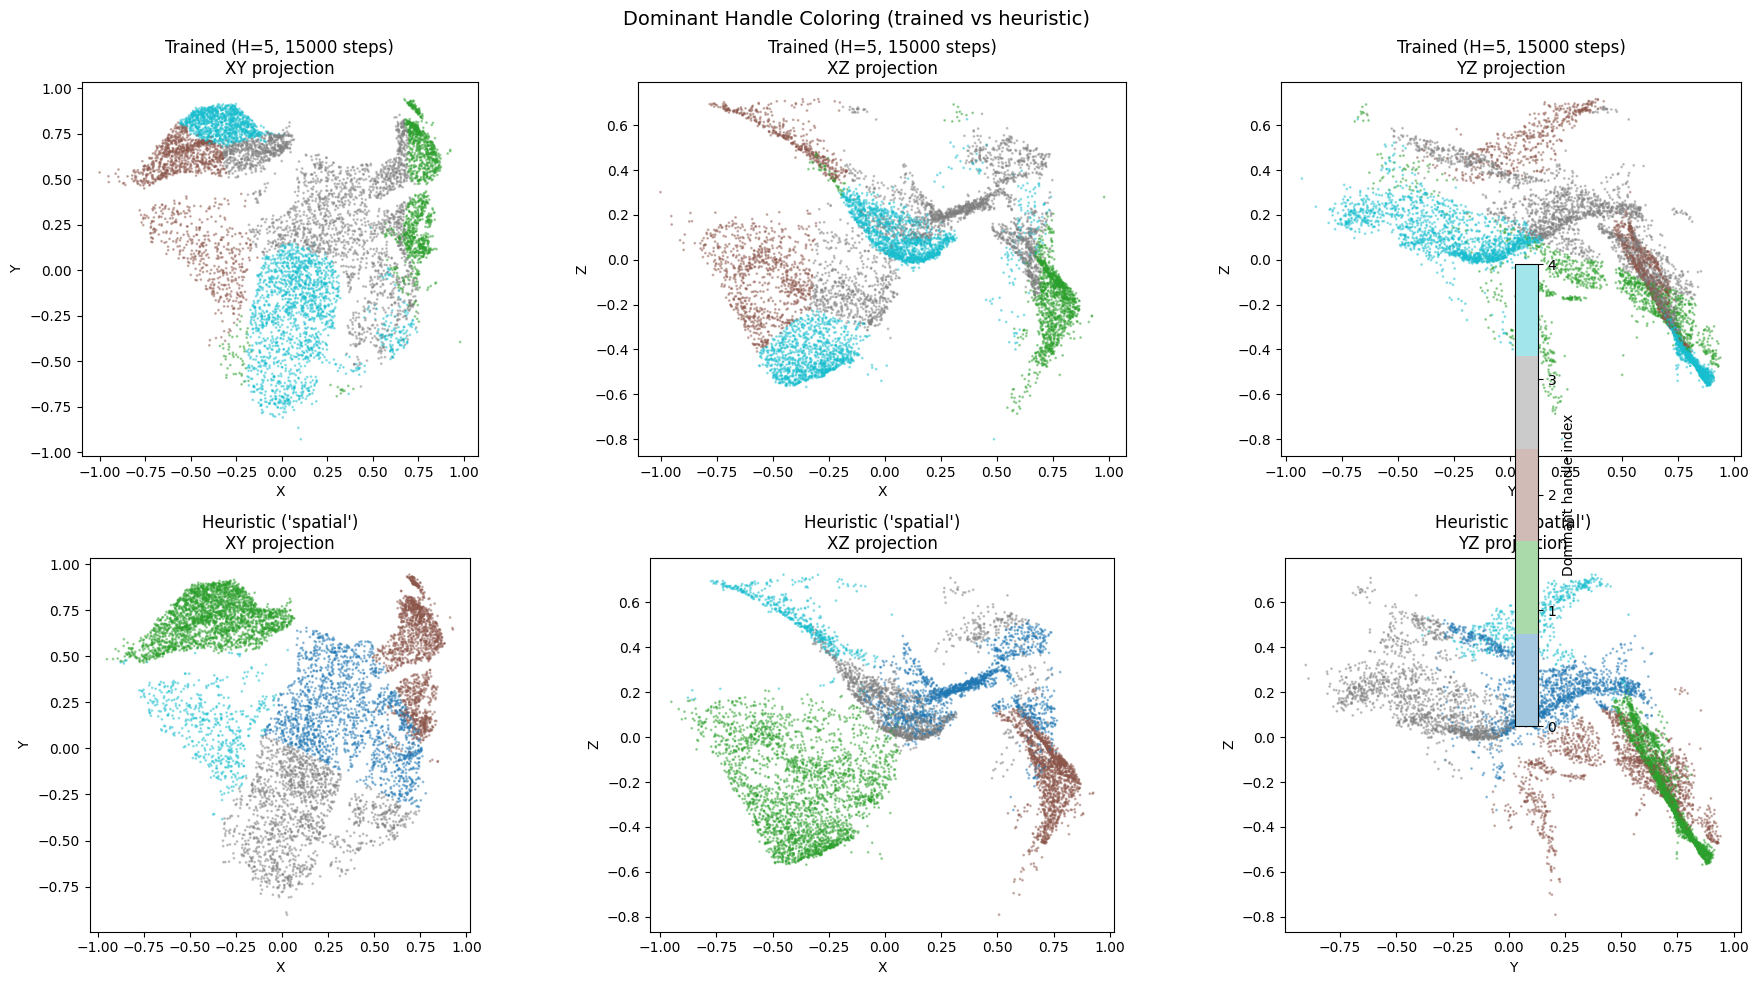

In [13]:
# ---- Plot 1: dominant handle coloring ----
cmap_h = plt.cm.get_cmap("tab10", NUM_HANDLES)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Dominant Handle Coloring (trained vs heuristic)", fontsize=14)

for row_i, stats in enumerate([stats_trained, stats_heuristic]):
    pts_np = stats["pts"]
    dom    = stats["dominant"]
    lbl    = stats["label"]
    for col_i, (xi, yi, vname) in enumerate([(0,1,"XY"), (0,2,"XZ"), (1,2,"YZ")]):
        ax = axes[row_i, col_i]
        sc = ax.scatter(pts_np[:, xi], pts_np[:, yi], c=dom,
                        cmap=cmap_h, vmin=0, vmax=NUM_HANDLES-1, s=1, alpha=0.4)
        ax.set_title(f"{lbl}\n{vname} projection")
        ax.set_xlabel(["X","Y","Z"][xi]); ax.set_ylabel(["X","Y","Z"][yi])
        ax.set_aspect("equal")

cbar = fig.colorbar(sc, ax=axes[:, 2], shrink=0.6, label="Dominant handle index")
cbar.set_ticks(range(NUM_HANDLES))

plt.tight_layout()
p3 = os.path.join(PLOTS_OUTPUT_DIR, "03_weight_dominant_handle.png")
plt.savefig(p3, dpi=150, bbox_inches="tight")
print("Saved:", p3)
plt.show()

Saved: ./skinning_weight_analysis_plots/04_weight_logit_spread.png


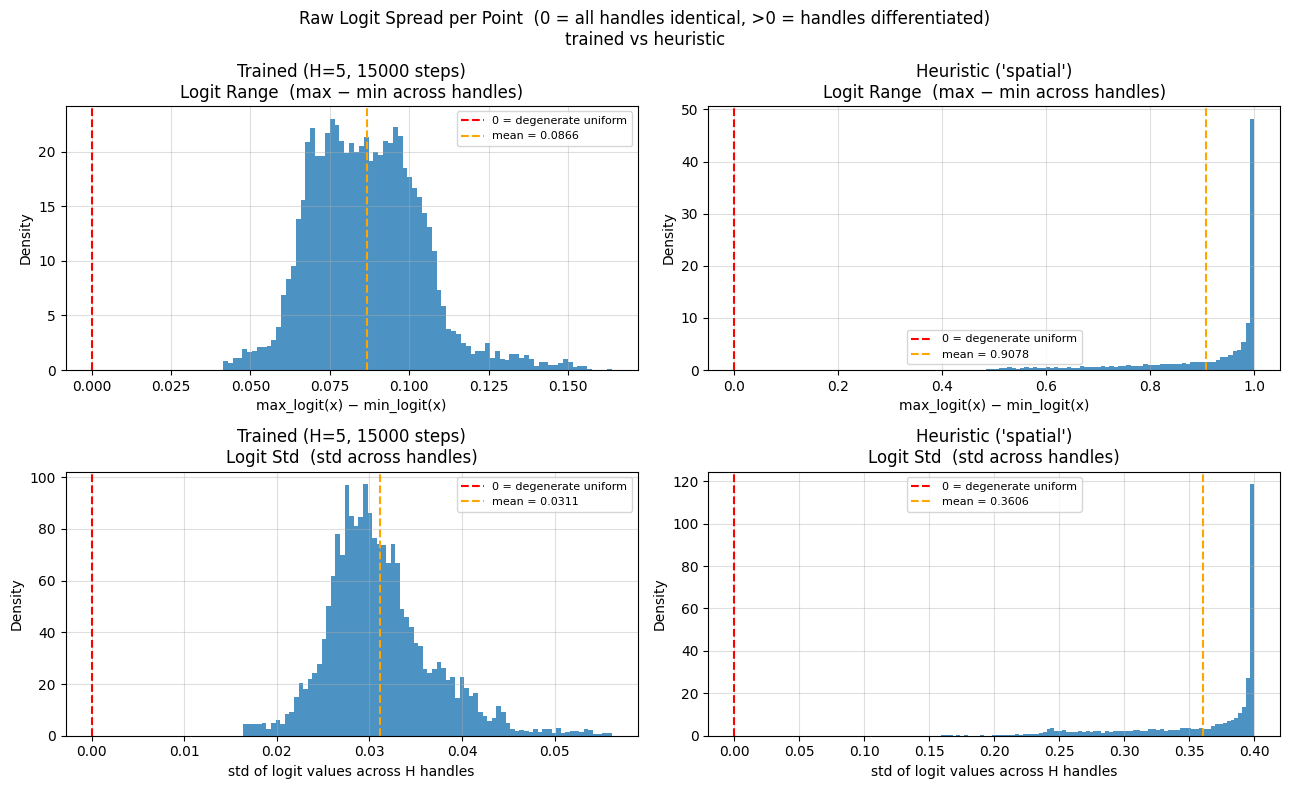

In [14]:
# ── Plot 4: raw logit-range and logit-std histograms ─────────────────────────
# logit_range = max_logit - min_logit per point.
#   If the network collapsed to uniform weights, ALL logits at a point are equal
#   → range = 0. Any positive range means the network has genuinely differentiated.
# logit_std measures the same thing (spread of logit values across handles per point).

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Raw Logit Spread per Point  (0 = all handles identical, >0 = handles differentiated)\n"
             "trained vs heuristic", fontsize=12)

for col_i, stats in enumerate([stats_trained, stats_heuristic]):
    # row 0: logit range
    ax = axes[0, col_i]
    lr = stats["logit_range"]
    ax.hist(lr, bins=80, density=True, alpha=0.8)
    ax.axvline(0.0, color="red",    ls="--", lw=1.5, label="0 = degenerate uniform")
    ax.axvline(lr.mean(), color="orange", ls="--", lw=1.5, label=f"mean = {lr.mean():.4f}")
    ax.set_title(f"{stats['label']}\nLogit Range  (max − min across handles)")
    ax.set_xlabel("max_logit(x) − min_logit(x)")
    ax.set_ylabel("Density"); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

    # row 1: logit std
    ax = axes[1, col_i]
    ls = stats["logit_std"]
    ax.hist(ls, bins=80, density=True, alpha=0.8)
    ax.axvline(0.0, color="red",    ls="--", lw=1.5, label="0 = degenerate uniform")
    ax.axvline(ls.mean(), color="orange", ls="--", lw=1.5, label=f"mean = {ls.mean():.4f}")
    ax.set_title(f"{stats['label']}\nLogit Std  (std across handles)")
    ax.set_xlabel("std of logit values across H handles")
    ax.set_ylabel("Density"); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

plt.tight_layout()
p4 = os.path.join(PLOTS_OUTPUT_DIR, "04_weight_logit_spread.png")
plt.savefig(p4, dpi=150, bbox_inches="tight")
print("Saved:", p4)
plt.show()

Saved: ./skinning_weight_analysis_plots/05a_per_handle_logit_maps.png


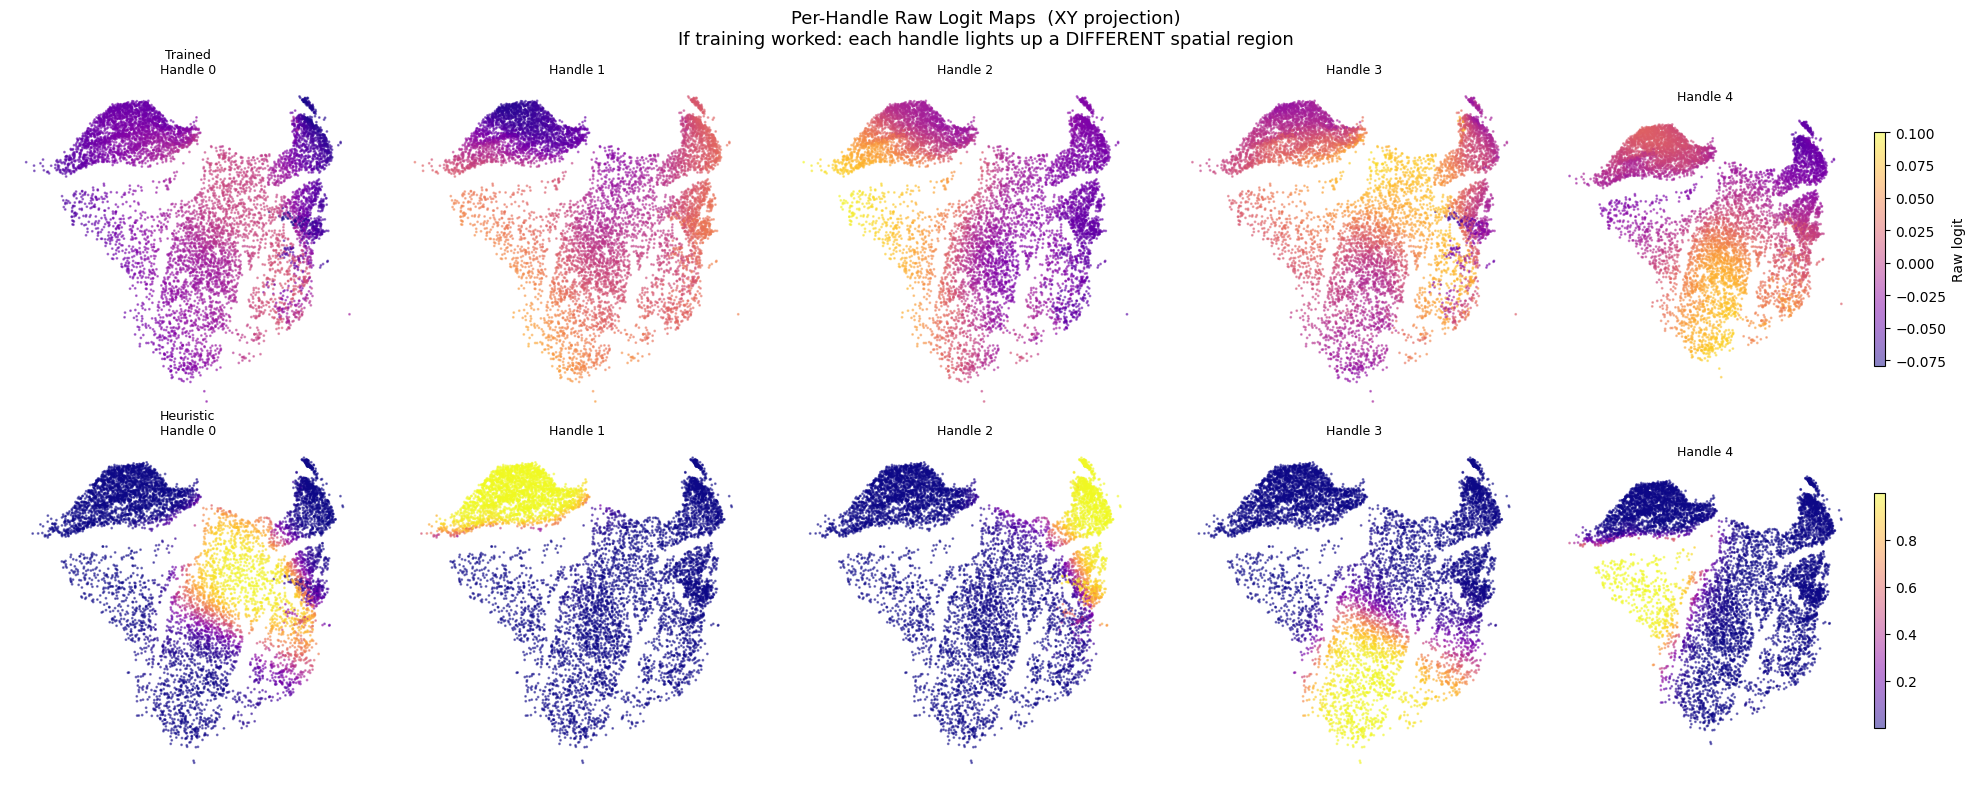

Saved: ./skinning_weight_analysis_plots/05b_handle_correlation.png


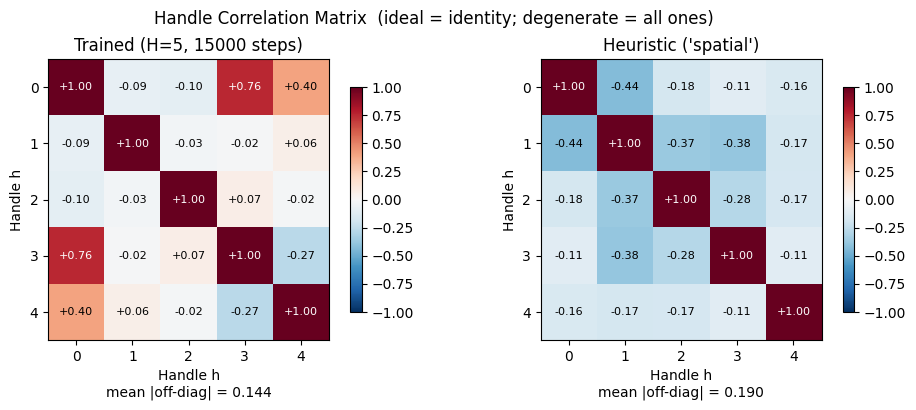

Saved: ./skinning_weight_analysis_plots/05c_logit_range_on_cloud.png


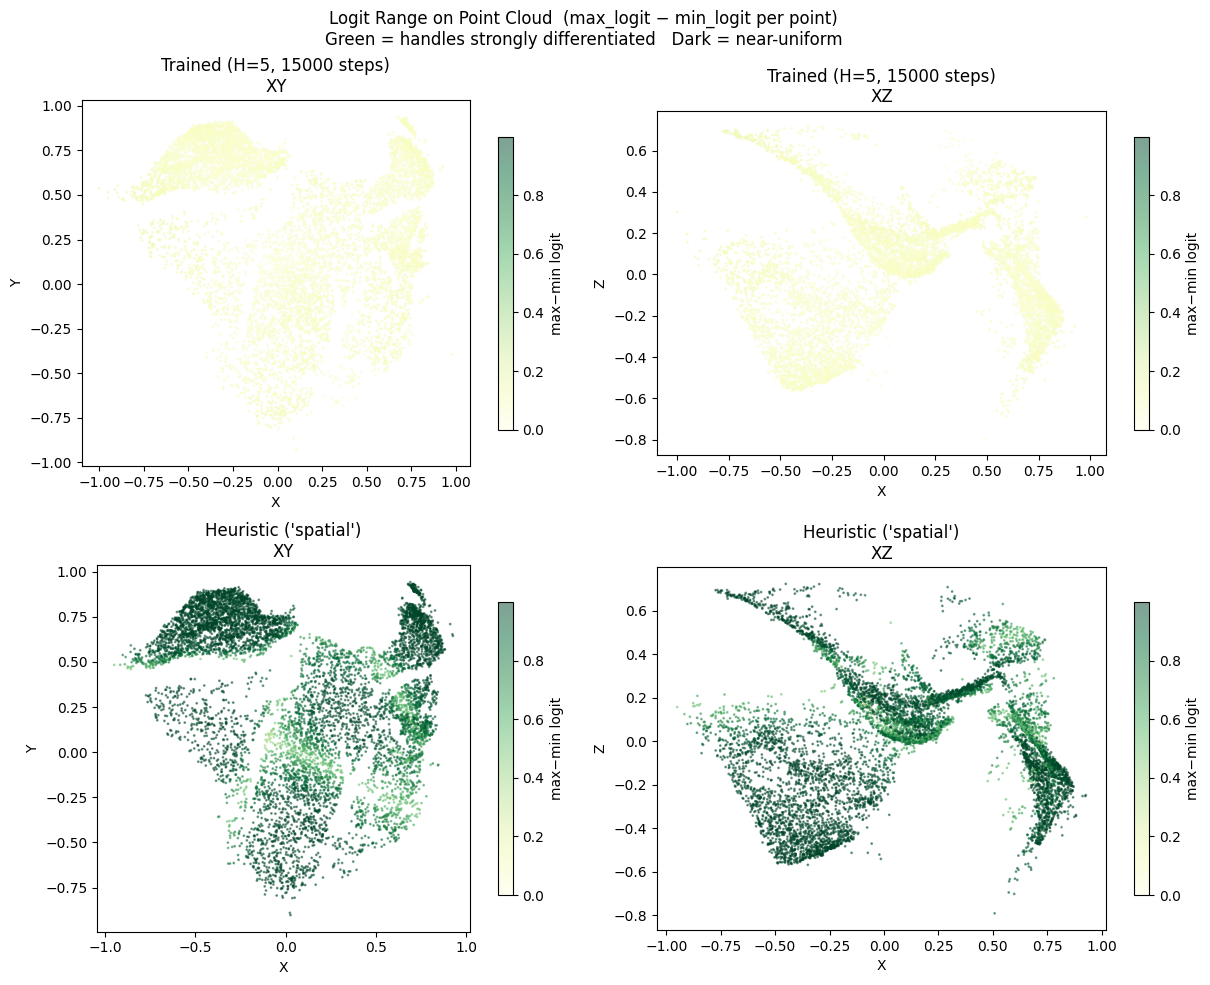

In [15]:
# ── Plot 5a: per-handle raw logit maps ───────────────────────────────────────
# Each subplot shows the raw logit value of ONE handle across all sampled points.
# If training worked: each handle has a distinct spatial footprint (bright region
# moves from handle to handle). If degenerate: all subplots look identical (flat).

fig, axes = plt.subplots(2, NUM_HANDLES, figsize=(NUM_HANDLES * 4, 8))
fig.suptitle("Per-Handle Raw Logit Maps  (XY projection)\n"
             "If training worked: each handle lights up a DIFFERENT spatial region",
             fontsize=13)

for row_i, stats in enumerate([stats_trained, stats_heuristic]):
    pts_np = stats["pts"]
    ph     = stats["per_handle"]                     # (sub, H) raw logits
    vmin, vmax = ph.min(), ph.max()
    for h in range(NUM_HANDLES):
        ax = axes[row_i, h]
        sc = ax.scatter(pts_np[:, 0], pts_np[:, 1], c=ph[:, h],
                        cmap="plasma", s=1, alpha=0.5, vmin=vmin, vmax=vmax)
        title_top = f"{'Trained' if row_i==0 else 'Heuristic'}" if h == 0 else ""
        ax.set_title(f"{title_top}\nHandle {h}", fontsize=9)
        ax.set_aspect("equal"); ax.axis("off")
    fig.colorbar(sc, ax=axes[row_i, -1], shrink=0.7,
                 label="Raw logit" if row_i == 0 else "")

plt.tight_layout()
p5a = os.path.join(PLOTS_OUTPUT_DIR, "05a_per_handle_logit_maps.png")
plt.savefig(p5a, dpi=150, bbox_inches="tight")
print("Saved:", p5a)
plt.show()

# ── Plot 5b: handle correlation matrix ───────────────────────────────────────
# Ideal: identity (each handle's spatial pattern is independent of every other).
# Degenerate: all-ones (all handles carry the same spatial signal).

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Handle Correlation Matrix  (ideal = identity; degenerate = all ones)", fontsize=12)

for ax, stats in zip(axes, [stats_trained, stats_heuristic]):
    g = stats["gram"]
    im = ax.imshow(g, cmap="RdBu_r", vmin=-1, vmax=1)
    for i in range(NUM_HANDLES):
        for j in range(NUM_HANDLES):
            ax.text(j, i, f"{g[i,j]:+.2f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(g[i,j]) > 0.5 else "black")
    ax.set_title(stats["label"])
    ax.set_xticks(range(NUM_HANDLES)); ax.set_yticks(range(NUM_HANDLES))
    ax.set_xlabel("Handle h"); ax.set_ylabel("Handle h")
    fig.colorbar(im, ax=ax, shrink=0.8)
    off_diag = (np.abs(g) - np.eye(NUM_HANDLES)).mean()
    ax.set_xlabel(f"Handle h\nmean |off-diag| = {off_diag:.3f}")

plt.tight_layout()
p5b = os.path.join(PLOTS_OUTPUT_DIR, "05b_handle_correlation.png")
plt.savefig(p5b, dpi=150, bbox_inches="tight")
print("Saved:", p5b)
plt.show()

# ── Plot 5c: logit range on point cloud ──────────────────────────────────────
# Logit range = max_logit(x) - min_logit(x).
# Green/yellow regions: handles are actively differentiated here.
# Dark red: handles barely differ → near-uniform at that point.

vmax_lr = float(np.percentile(
    np.concatenate([stats_trained["logit_range"], stats_heuristic["logit_range"]]), 99))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Logit Range on Point Cloud  (max_logit − min_logit per point)\n"
             "Green = handles strongly differentiated   Dark = near-uniform", fontsize=12)

for row_i, stats in enumerate([stats_trained, stats_heuristic]):
    pts_np = stats["pts"]
    lr     = stats["logit_range"]
    lbl    = stats["label"]
    for col_i, (xi, yi, vname) in enumerate([(0, 1, "XY"), (0, 2, "XZ")]):
        ax = axes[row_i, col_i]
        sc = ax.scatter(pts_np[:, xi], pts_np[:, yi], c=lr,
                        cmap="YlGn", s=1, alpha=0.5, vmin=0, vmax=vmax_lr)
        fig.colorbar(sc, ax=ax, shrink=0.8, label="max−min logit")
        ax.set_title(f"{lbl}\n{vname}")
        ax.set_xlabel(["X","Y","Z"][xi]); ax.set_ylabel(["X","Y","Z"][yi])
        ax.set_aspect("equal")

plt.tight_layout()
p5c = os.path.join(PLOTS_OUTPUT_DIR, "05c_logit_range_on_cloud.png")
plt.savefig(p5c, dpi=150, bbox_inches="tight")
print("Saved:", p5c)
plt.show()

## 10) Build evaluation scenes (trained vs heuristic)

One scene per object.  Tool-contact constraint (grasp) + AABB anchor boundary are applied identically to both.

In [16]:
def torch_to_np(x):
    return x.detach().cpu().numpy()

@torch.no_grad()
def chamfer_l2(a, b, max_a=2048, max_b=2048):
    if a.shape[0] > max_a:
        a = a[torch.randint(0, a.shape[0], (max_a,), device=a.device)]
    if b.shape[0] > max_b:
        b = b[torch.randint(0, b.shape[0], (max_b,), device=b.device)]
    d   = torch.cdist(a, b)
    ab  = (d.min(dim=1).values ** 2).mean()
    ba  = (d.min(dim=0).values ** 2).mean()
    return ab + ba, torch.sqrt((ab + ba).clamp_min(1e-12))

def build_anchor_mask_cpu(internal_rest, eps_ratio=0.03):
    mins = internal_rest.min(dim=0).values
    maxs = internal_rest.max(dim=0).values
    eps  = eps_ratio * (maxs - mins).clamp_min(1e-8)
    on   = (
        (internal_rest[:, 0] <= mins[0] + eps[0]) | (internal_rest[:, 0] >= maxs[0] - eps[0]) |
        (internal_rest[:, 1] <= mins[1] + eps[1]) | (internal_rest[:, 1] >= maxs[1] - eps[1]) |
        (internal_rest[:, 2] <= mins[2] + eps[2]) | (internal_rest[:, 2] >= maxs[2] - eps[2])
    )
    mask = torch.zeros(internal_rest.shape[0], dtype=torch.bool)
    mask[on.nonzero(as_tuple=False).squeeze(1).cpu()] = True
    return mask

def make_scene(sim_obj, num_qp=800, newton_steps=30, timestep=0.01):
    scene = kal.physics.simplicits.SimplicitsScene()
    scene.max_newton_steps = int(newton_steps)
    scene.timestep         = float(timestep)
    scene.direct_solve     = True
    obj_idx = scene.add_object(sim_obj, num_qp=int(num_qp))
    scene.set_scene_gravity(acc_gravity=torch.tensor([0., 0., 0.], device=pts.device, dtype=pts.dtype))
    scene.reset_scene()
    return scene, obj_idx

def compute_constraint_geometry(internal_rest, eps_ratio=0.03, K_GRASP_PTS=10):
    """Compute anchor/grasp masks and targets from QP positions.
    Does NOT call any scene API — result can be shared across scenes."""
    t0  = tool_t[0]
    d2  = torch.sum((internal_rest - t0[None, :]) ** 2, dim=1)
    grasp_ids     = torch.topk(d2, k=int(K_GRASP_PTS), largest=False).indices
    grasp_ids_cpu = grasp_ids.cpu()

    grasp_mask_cpu = torch.zeros(internal_rest.shape[0], dtype=torch.bool)
    grasp_mask_cpu[grasp_ids_cpu] = True

    p0  = internal_rest[grasp_ids].clone()
    t0c = t0.clone()
    def grasp_targets(t_idx): return p0 + (tool_t[t_idx] - t0c)[None, :]

    anchor_mask_cpu = build_anchor_mask_cpu(internal_rest, eps_ratio=float(eps_ratio))
    anchor_mask_cpu[grasp_ids_cpu] = False          # don't double-pin grasp pts
    anchor_ids_cpu  = anchor_mask_cpu.nonzero(as_tuple=False).squeeze(1)
    anchor_target   = internal_rest[anchor_ids_cpu.to(internal_rest.device)].clone()

    return dict(
        internal_rest   = internal_rest,
        grasp_ids       = grasp_ids,
        grasp_ids_cpu   = grasp_ids_cpu,
        grasp_mask_cpu  = grasp_mask_cpu,
        grasp_targets   = grasp_targets,
        anchor_mask_cpu = anchor_mask_cpu,
        anchor_ids_cpu  = anchor_ids_cpu,
        anchor_target   = anchor_target,
    )

def register_constraints(scene, obj_idx, cg, K_ANCHOR=1e7, K_GRASP=1e5):
    """Register pre-computed constraint geometry onto a scene."""
    _gm = cg["grasp_mask_cpu"]
    _am = cg["anchor_mask_cpu"]
    scene.set_object_boundary_condition(
        obj_idx=obj_idx, name="grasp",
        fcn=lambda _: _gm, bdry_penalty=float(K_GRASP),
        pinned_x=cg["grasp_targets"](0),
    )
    scene.set_object_boundary_condition(
        obj_idx=obj_idx, name="anchor",
        fcn=lambda _: _am, bdry_penalty=float(K_ANCHOR),
        pinned_x=cg["anchor_target"],
    )
    return dict(**cg, K_GRASP=float(K_GRASP), K_ANCHOR=float(K_ANCHOR))

# ── Build both scenes with the SAME QP seed so quadrature point positions
#    are identical → anchor/grasp indices computed once apply to both scenes.
QP_SEED = 42

torch.manual_seed(QP_SEED)
scene_tr,  idx_tr  = make_scene(sim_obj_trained,   num_qp=800, newton_steps=30)

# Compute constraint geometry once from trained scene's QPs
cg_shared = compute_constraint_geometry(scene_tr.get_object_deformed_pts(idx_tr))

torch.manual_seed(QP_SEED)            # same seed → same QP sampling in heuristic scene
scene_heu, idx_heu = make_scene(sim_obj_heuristic, num_qp=800, newton_steps=30)

scenes = {
    "trained":   dict(scene=scene_tr,  obj_idx=idx_tr,
                      name="Trained",
                      cons=register_constraints(scene_tr,  idx_tr,  cg_shared)),
    "heuristic": dict(scene=scene_heu, obj_idx=idx_heu,
                      name=f"Heuristic ({HEURISTIC_TYPE})",
                      cons=register_constraints(scene_heu, idx_heu, cg_shared)),
}

for k, v in scenes.items():
    print(f"{k:>10}:  grasp_pts={v['cons']['grasp_ids'].shape[0]}"
          f"  anchor_pts={v['cons']['anchor_ids_cpu'].shape[0]}"
          f"  (shared geometry — same QP seed={QP_SEED})")

# ── RGB loading ───────────────────────────────────────────────────────────────
def _to_k3d_colors(rgb_arr):
    """Convert (N,3+) float[0-1] or uint8[0-255] array → uint32 k3d color array."""
    r = np.asarray(rgb_arr, dtype=np.float32)[:, :3]
    if r.max() <= 1.001:
        r = (r * 255.0).clip(0, 255)
    r = r.astype(np.uint8)
    return ((r[:, 0].astype(np.uint32) << 16) |
            (r[:, 1].astype(np.uint32) << 8)  |
             r[:, 2].astype(np.uint32))

# Rest-frame RGB → colours that travel with simulated surface points
_rgb_rest = real_seq[_rest_list_idx].get("rgb", None)
if _rgb_rest is not None and np.asarray(_rgb_rest).ndim == 2:
    pts_colors_k3d = _to_k3d_colors(_rgb_rest)
    print(f"Rest-frame RGB loaded: shape={np.asarray(_rgb_rest).shape}")
else:
    pts_colors_k3d = None
    print("WARNING: no RGB in rest frame — falling back to flat colour")

# Per-frame RGB → colours for the real-PCD overlay
_fid_to_seq_idx = {int(fr["frame_id"]): i for i, fr in enumerate(real_seq)}
real_rgb_k3d = []
for fid in frame_ids:
    _fr = real_seq[_fid_to_seq_idx[fid]]
    _rgb = _fr.get("rgb", None)
    if _rgb is not None and np.asarray(_rgb).ndim == 2:
        real_rgb_k3d.append(_to_k3d_colors(_rgb))
    else:
        real_rgb_k3d.append(None)
print(f"Per-frame RGB: {sum(x is not None for x in real_rgb_k3d)}/{len(real_rgb_k3d)} frames OK")

/home/nan/miniconda3/envs/subspace_mfem/lib/python3.10/site-packages/warp/_src/torch.py:280: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  if t.grad is not None:
/home/nan/Desktop/kaolin/kaolin/physics/utils/warp_utilities.py:263: UserWarning: Sparse BSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  torch_weights = ctor(


   trained:  grasp_pts=10  anchor_pts=29  (shared geometry — same QP seed=42)
 heuristic:  grasp_pts=10  anchor_pts=29  (shared geometry — same QP seed=42)
Rest-frame RGB loaded: shape=(45038, 3)
Per-frame RGB: 125/125 frames OK


## 11) Interactive side-by-side simulation comparison (trained vs heuristic)

- **Next**: step both simulations by one frame.
- **Run / Stop**: run continuously.
- **Reset**: return to frame `eval_T0`.

Per-frame logs (grasp error, Chamfer to real) are accumulated in `eval_logs` and periodically written to CSV.

In [17]:
# ── k3d helpers ───────────────────────────────────────────────────────────────
def make_k3d_plot(key):
    sc   = scenes[key]["scene"]
    oi   = scenes[key]["obj_idx"]
    cons = scenes[key]["cons"]
    p    = k3d.plot(camera_auto_fit=True)

    # Simulated surface points — RGB colours travel with the particles
    surf_pos = torch_to_np(sc.get_object_deformed_pts(oi, orig_pts))
    if pts_colors_k3d is not None:
        surf = k3d.points(surf_pos, colors=pts_colors_k3d, point_size=0.01)
    else:
        surf = k3d.points(surf_pos, point_size=0.01,
                          color=(0x4488ff if key == "trained" else 0x44cc44))

    # Internal QP overlays (grasp = red, anchor = lime)
    qp_np = torch_to_np(sc.get_object_deformed_pts(oi))
    gp = k3d.points(qp_np[cons["grasp_ids_cpu"].numpy()],  point_size=0.06, color=0xff2222)
    ap = k3d.points(qp_np[cons["anchor_ids_cpu"].numpy()], point_size=0.04, color=0x00ff00)

    # Tool marker + trajectory
    tp = k3d.points(torch_to_np(tool_t[0])[None, :], point_size=0.10, color=0xffff00)
    tl = k3d.line(torch_to_np(tool_t), color=0xffa500, width=0.01)

    # Real PCD overlay — hidden by default, toggled with checkbox
    real_pos0 = torch_to_np(real_xyz_norm_aligned[eval_T0])
    if real_rgb_k3d[eval_T0] is not None:
        real_ol = k3d.points(real_pos0, colors=real_rgb_k3d[eval_T0], point_size=0.008)
    else:
        real_ol = k3d.points(real_pos0, color=0xbbbbbb, point_size=0.008)
    real_ol.visible = False

    for obj in [surf, gp, ap, tp, tl, real_ol]:
        p += obj
    return p, dict(surf=surf, grasp=gp, anchor=ap, tool=tp, real=real_ol)

def refresh_k3d(key, ti):
    sc   = scenes[key]["scene"]
    oi   = scenes[key]["obj_idx"]
    cons = scenes[key]["cons"]
    h    = k3d_handles[key]

    # Simulated surface (colours are fixed, only positions change)
    h["surf"].positions  = torch_to_np(sc.get_object_deformed_pts(oi, orig_pts))
    qp_np = torch_to_np(sc.get_object_deformed_pts(oi))
    h["grasp"].positions = qp_np[cons["grasp_ids_cpu"].numpy()]
    h["anchor"].positions= qp_np[cons["anchor_ids_cpu"].numpy()]
    h["tool"].positions  = torch_to_np(tool_t[ti])[None, :]

    # Real overlay — update position + colour every frame so it's ready when toggled on
    if ti < len(real_xyz_norm_aligned):
        h["real"].positions = torch_to_np(real_xyz_norm_aligned[ti])
        if real_rgb_k3d[ti] is not None:
            h["real"].colors = real_rgb_k3d[ti]

# ── Build k3d views ────────────────────────────────────────────────────────────
k3d_plots   = {}
k3d_handles = {}
out_tr  = widgets.Output(layout={"border":"1px solid #eee", "width":"50%", "height":"520px"})
out_heu = widgets.Output(layout={"border":"1px solid #eee", "width":"50%", "height":"520px"})

for key, out_w, lbl_txt in [
    ("trained",   out_tr,  "Trained (RGB)"),
    ("heuristic", out_heu, f"Heuristic ({HEURISTIC_TYPE}) (RGB)"),
]:
    p, h = make_k3d_plot(key)
    k3d_plots[key] = p
    k3d_handles[key] = h
    out_w.clear_output(wait=True)
    with out_w:
        print(lbl_txt)
        p.display()

display(widgets.HBox([out_tr, out_heu]))

# ── Logging ────────────────────────────────────────────────────────────────────
eval_logs   = []
eval_outdir = os.path.join(os.getcwd(), "eval_compare_logs")
os.makedirs(eval_outdir, exist_ok=True)
eval_stamp    = datetime.now().strftime("%Y%m%d-%H%M%S")
eval_csv_path = os.path.join(eval_outdir, f"eval_{eval_stamp}.csv")
print("Eval CSV →", eval_csv_path)

# ── Simulation state ───────────────────────────────────────────────────────────
ti_state = {"ti": eval_T0}
running  = {"flag": False}
runner   = {"thread": None}

def reset_all_scenes():
    for k in scenes:
        scenes[k]["scene"].reset_scene()
        cons = scenes[k]["cons"]
        scenes[k]["scene"].update_object_boundary_pinned_x("grasp",  cons["grasp_targets"](0))
        scenes[k]["scene"].update_object_boundary_pinned_x("anchor", cons["anchor_target"])

def step_one(key, ti):
    sc   = scenes[key]["scene"]
    oi   = scenes[key]["obj_idx"]
    cons = scenes[key]["cons"]
    sc.update_object_boundary_pinned_x("grasp", cons["grasp_targets"](ti))
    sc.run_sim_step()
    internal_now = sc.get_object_deformed_pts(oi)
    grasp_err = torch.norm(internal_now[cons["grasp_ids"]] - cons["grasp_targets"](ti), dim=1).mean()
    chamfer2 = chamfer = None
    if ti < len(real_xyz_norm_aligned):
        rp = real_xyz_norm_aligned[ti]
        if isinstance(rp, np.ndarray):
            rp = torch.from_numpy(rp).to(device=internal_now.device, dtype=internal_now.dtype)
        else:
            rp = rp.to(device=internal_now.device, dtype=internal_now.dtype)
        chamfer2, chamfer = chamfer_l2(internal_now, rp)
    return dict(
        split=("train" if ti < train_T else "test"), ti=int(ti), model=key,
        grasp_err=float(grasp_err.item()),
        chamfer2=(None if chamfer2 is None else float(chamfer2.item())),
        chamfer =(None if chamfer  is None else float(chamfer.item())),
    )

# ── Widgets ────────────────────────────────────────────────────────────────────
substeps = widgets.IntSlider(value=1, min=1, max=10, step=1, description="substeps")
sleep_s  = widgets.FloatSlider(value=0.0, min=0.0, max=0.3, step=0.01, description="sleep(s)")
chk_real = widgets.Checkbox(value=False, description="Show real PCD")
btn_next  = widgets.Button(description="Next")
btn_run   = widgets.Button(description="Run")
btn_stop  = widgets.Button(description="Stop")
btn_reset = widgets.Button(description="Reset")
info_lbl  = widgets.Label()
log_out   = widgets.Output(layout={"border":"1px solid #ddd", "height":"180px", "overflow_y":"auto"})

def _toggle_real(change):
    for h in k3d_handles.values():
        h["real"].visible = change["new"]
chk_real.observe(_toggle_real, names="value")

def do_next(_=None):
    ti = ti_state["ti"]
    if ti >= eval_T1:
        info_lbl.value = "Done."; return
    with log_out:
        print(f"\n=== ti={ti} (frame {frame_ids[ti]}) ===")
    for _ in range(substeps.value):
        for key in ("trained", "heuristic"):
            row = step_one(key, ti)
            eval_logs.append(row)
            with log_out:
                print(f"  {key:>10}  grasp_err={row['grasp_err']:.5f}  chamfer={row['chamfer']}")
        refresh_k3d("trained",   ti)
        refresh_k3d("heuristic", ti)
        if sleep_s.value > 0:
            time.sleep(sleep_s.value)
    if len(eval_logs) % 20 == 0:
        pd.DataFrame(eval_logs).to_csv(eval_csv_path, index=False)
    rt = next((r for r in reversed(eval_logs) if r["ti"] == ti and r["model"] == "trained"),   None)
    rh = next((r for r in reversed(eval_logs) if r["ti"] == ti and r["model"] == "heuristic"), None)
    if rt and rh and rt["chamfer"] and rh["chamfer"]:
        info_lbl.value = (f"ti={ti:04d}/{eval_T1-1}  frame={frame_ids[ti]}"
                          f"  Δchamfer(heu-trained)={rh['chamfer']-rt['chamfer']:+.5f}")
    else:
        info_lbl.value = f"ti={ti:04d}/{eval_T1-1}  frame={frame_ids[ti]}"
    ti_state["ti"] += 1

def run_loop():
    running["flag"] = True
    while running["flag"] and ti_state["ti"] < eval_T1:
        do_next()
    running["flag"] = False

def do_run(_=None):
    if running["flag"]: return
    runner["thread"] = threading.Thread(target=run_loop, daemon=True)
    runner["thread"].start()

def do_stop(_=None):
    running["flag"] = False

def do_reset(_=None):
    running["flag"] = False
    ti_state["ti"]  = eval_T0
    reset_all_scenes()
    refresh_k3d("trained",   eval_T0)
    refresh_k3d("heuristic", eval_T0)
    with log_out:
        print("\n=== RESET ===")
    info_lbl.value = "Reset."

btn_next.on_click(do_next)
btn_run.on_click(do_run)
btn_stop.on_click(do_stop)
btn_reset.on_click(do_reset)

display(
    widgets.HBox([btn_next, btn_run, btn_stop, btn_reset]),
    widgets.HBox([substeps, sleep_s, chk_real]),
    info_lbl,
    log_out,
)

Eval CSV → /home/nan/Desktop/kaolin/examples/tutorial/physics/eval_compare_logs/eval_20260414-221420.csv


Label(value='')

Output(layout=Layout(border='1px solid #ddd', height='180px', overflow_y='auto'))

## 12) Simulation metric plots → save to `PLOTS_OUTPUT_DIR`

Run this cell **after** stepping through the simulation above (or running it to completion).

Saved eval CSV: /home/nan/Desktop/kaolin/examples/tutorial/physics/eval_compare_logs/eval_20260414-221420.csv
Eval log: 250 rows


,split,ti,model,grasp_err,chamfer2,chamfer
245,test,122,heuristic,0.145431,0.011060,0.105166
246,test,123,trained,0.120222,0.007788,0.088250
247,test,123,heuristic,0.142808,0.010736,0.103616
248,test,124,trained,0.123968,0.008063,0.089796
249,test,124,heuristic,0.147603,0.010604,0.102974


Saved: ./skinning_weight_analysis_plots/06_sim_grasp_err.png


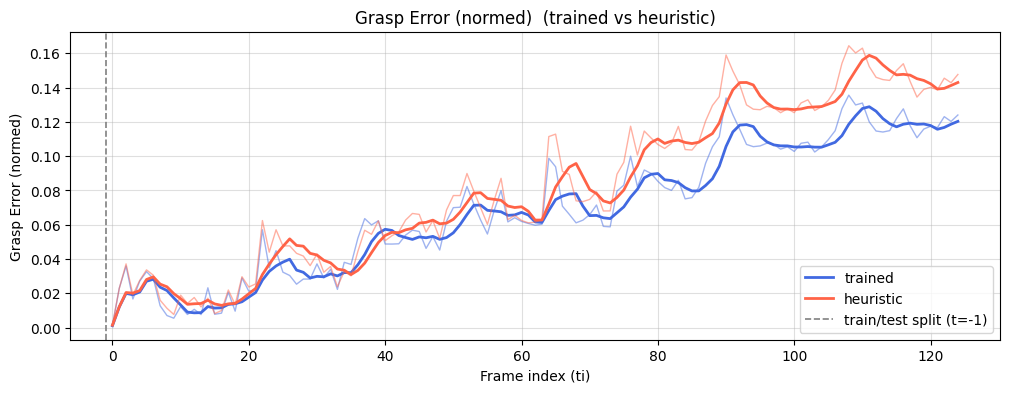

Saved: ./skinning_weight_analysis_plots/06_sim_chamfer.png


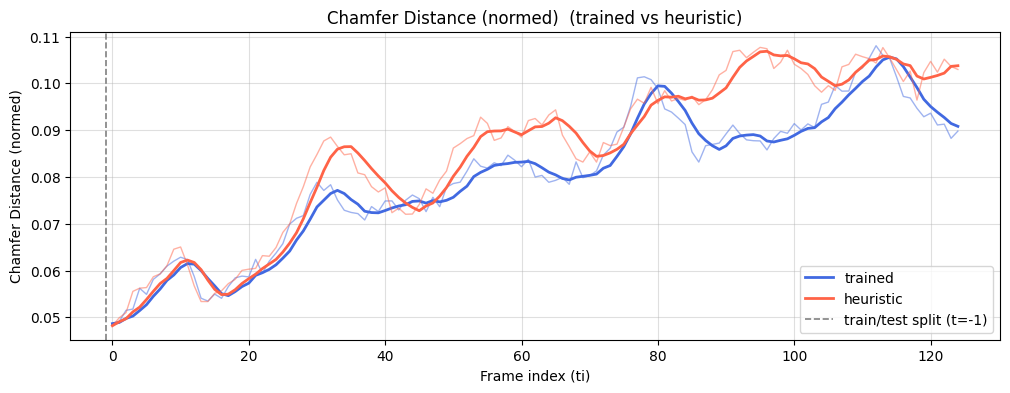

,model,split,grasp_err_mean,grasp_err_med,chamfer_mean,chamfer_med
0,heuristic,test,0.082643,0.074365,0.085633,0.088512
1,trained,test,0.069558,0.065848,0.080182,0.081893


Saved summary: /home/nan/Desktop/kaolin/examples/tutorial/physics/eval_compare_logs/eval_20260414-221420_summary.csv


In [19]:
# Flush final logs
if eval_logs:
    pd.DataFrame(eval_logs).to_csv(eval_csv_path, index=False)
    print("Saved eval CSV:", eval_csv_path)

if not os.path.exists(eval_csv_path):
    raise FileNotFoundError(f"No eval log yet – run the simulation first: {eval_csv_path}")

df_eval = pd.read_csv(eval_csv_path)
print(f"Eval log: {len(df_eval)} rows")
display(df_eval.tail())

colours = {"trained": "royalblue", "heuristic": "tomato"}

for metric, ylabel in [("grasp_err", "Grasp Error (normed)"), ("chamfer", "Chamfer Distance (normed)")]:
    if metric not in df_eval.columns:
        continue
    fig, ax = plt.subplots(figsize=(12, 4))
    for model in ("trained", "heuristic"):
        sdf = df_eval[df_eval["model"] == model].sort_values("ti")
        if sdf[metric].isna().all(): continue
        ax.plot(sdf["ti"], sdf[metric], lw=1, alpha=0.5, color=colours[model])
        smooth = sdf[metric].rolling(5, min_periods=1).mean()
        ax.plot(sdf["ti"], smooth, lw=2, color=colours[model], label=model)
    ax.axvline(train_T - 1, color="gray", ls="--", lw=1.2, label=f"train/test split (t={train_T-1})")
    ax.set_title(f"{ylabel}  (trained vs heuristic)")
    ax.set_xlabel("Frame index (ti)"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.4)
    pname = os.path.join(PLOTS_OUTPUT_DIR, f"06_sim_{metric}.png")
    plt.savefig(pname, dpi=150, bbox_inches="tight")
    print("Saved:", pname)
    plt.show()

# Summary table
if len(df_eval) > 0:
    summary = df_eval.groupby(["model", "split"]).agg(
        grasp_err_mean  = ("grasp_err", "mean"),
        grasp_err_med   = ("grasp_err", "median"),
        chamfer_mean    = ("chamfer",   "mean"),
        chamfer_med     = ("chamfer",   "median"),
    ).reset_index()
    display(summary)
    summary_path = eval_csv_path.replace(".csv", "_summary.csv")
    summary.to_csv(summary_path, index=False)
    print("Saved summary:", summary_path)